In [13]:
import os
import pandas as pd
import re, string, nltk
from datasets import load_dataset
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk import word_tokenize, pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
import time

In [14]:
# Создание папки для nltk данных, если её нет
nltk_data_dir = os.path.expanduser('../nltk_data')
if not os.path.exists(nltk_data_dir):
    os.makedirs(nltk_data_dir)

# Добавление пути в nltk
nltk.data.path.append(nltk_data_dir)

# Загрузка всех необходимых ресурсов
resources = ['punkt', 'wordnet', 'omw-1.4', 'punkt_tab', 
             'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'stopwords']

for resource in resources:
    try:
        nltk.download(resource, download_dir=nltk_data_dir, quiet=False)
    except:
        print(f"Ресурс {resource} уже загружен или произошла ошибка")

[nltk_data] Downloading package punkt to ../nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to ../nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to ../nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to ../nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ../nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ../nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to ../nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[{}[\]()<>]', '', text)
    text = re.sub(r'\d+\.\d+\.\d+\.\d+', '', text)
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    text = re.sub(email_pattern, '', text)
    text = re.sub(r'\S+/\S+/\S+', '', text)
    text = re.sub(r'\S+\.\S+/\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[`"\']{2,}', ' ', text)
    text = re.sub(r'[`"\']', ' ', text)
    text = re.sub(r'[\[\]{}()<>]', ' ', text)
    text = re.sub(r'(\w+)-(\d+)', r'\1\2', text)
    text = re.sub(r'(\d+)-(\w+)', r'\1\2', text)
    smile_pattern = r'[:;=][\-^]?[)D\(\[\]pP]+'
    text = re.sub(smile_pattern, '', text)
    text = re.sub(r'([!?.,])\1+', r'\1', text)
    text = re.sub(r'-{2,}', ' ', text)
    text = re.sub(r'\+?\d[\d\s\-\(\)]{7,}\d', '', text)
    text = re.sub(r'[^\w\s]', ' ', text) 
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

stop_words = set(stopwords.words("english"))
additional_stops = {
    'would', 'could', 'should', 'might', 'may', 'get', 'go', 'see', 
    'know', 'like', 'want', 'need', 'say', 'think', 'come', 'take',
    'use', 'make', 'well', 'also', 'even', 'many', 'much', 'still',
    'however', 'though', 'although', 'since', 'yet', 'already'
}
stop_words.update(additional_stops)

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

lemmatizer = nltk.WordNetLemmatizer()

def preprocess_with_lemmatization(text, pos_filter="all"):
    tokens = word_tokenize(clean_text(text))
    tagged = pos_tag(tokens)
    lemmatized_tokens = []
    for token, tag in tagged:
        if token in stop_words or token in string.punctuation:
            continue
        is_noun_adj = tag.startswith('N') or tag.startswith('J')
        if pos_filter == "nouns_adj" and not is_noun_adj:
            continue
        lemmatized_tokens.append(lemmatizer.lemmatize(token, get_wordnet_pos(tag)))
    return " ".join(lemmatized_tokens)

stemmer = PorterStemmer()
def preprocess_with_stemming(text):
    tokens = word_tokenize(clean_text(text))
    res = []
    for token in tokens:
        if token in stop_words or token in string.punctuation: continue
        res.append(stemmer.stem(token))
    return " ".join(res)

In [16]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("emotion")
train_df = pd.DataFrame(dataset["train"])
test_df  = pd.DataFrame(dataset["test"])

train_df['text'] = train_df['text'].astype(str)
test_df['text']  = test_df['text'].astype(str)

print(f"✅ Загружено Emotions: Train={len(train_df)}, Test={len(test_df)}")
print(f"📊 Классы: {sorted(train_df['label'].unique())} (6 эмоций)\n")

✅ Загружено Emotions: Train=16000, Test=2000
📊 Классы: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (6 эмоций)



In [17]:
print("🔄 Предобработка текстов эмоций...")
for df in [train_df, test_df]:
    df['text_simple'] = df['text'].apply(lambda x: preprocess_with_lemmatization(x, 'all'))
    df['text_pos'] = df['text'].apply(lambda x: preprocess_with_lemmatization(x, 'nouns_adj'))
    df['text_stem'] = df['text'].apply(preprocess_with_stemming)
    
print("✅ Предобработка эмоций завершена")

🔄 Предобработка текстов эмоций...
✅ Предобработка эмоций завершена


In [18]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Параметры для кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'f1_macro': 'f1_macro',
    'f1_micro': 'f1_micro'
}

# Слова для обработки
preprocessing_methods = {
    'Lemmatization (all)': 'text_simple',
    'Lemmatization (nouns+adj)': 'text_pos',
    'Stemming': 'text_stem'
}

# Словарь для всех результатов
all_results = {}

print("="*80)
print("ОБУЧЕНИЕ НА ТРЕХ ВАРИАНТАХ ПРЕДОБРАБОТКИ")
print("="*80)

ОБУЧЕНИЕ НА ТРЕХ ВАРИАНТАХ ПРЕДОБРАБОТКИ


In [35]:
# Модели
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

# Цикл по всем методам предобработки
for prep_name, text_column in preprocessing_methods.items():
    print("\n" + "="*80)
    print(f"📋 МЕТОД ПРЕДОБРАБОТКИ: {prep_name}")
    print("="*80 + "\n")
    
    # TF-IDF векторизация
    print(f"🔄 Векторизация текстов ({prep_name})...")
    vectorizer = TfidfVectorizer(
        max_features=1000,
        min_df=2,
        max_df=0.8,
        ngram_range=(1, 2),
        stop_words='english'
    )
    
    X_train = vectorizer.fit_transform(train_df[text_column])
    y_train = train_df['label'].values
    
    X_test = vectorizer.transform(test_df[text_column])
    y_test = test_df['label'].values
    
    print(f"✅ X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"📊 Количество векторизованных признаков: {X_train.shape[1]}\n")
    
    # Кросс-валидация
    print("РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ (5-fold StratifiedKFold)")
    print("-"*80)
    
    cv_results_prep = {}
    
    for model_name, model in models.items():
        # Кросс-валидация
        scores = cross_validate(
            model, X_train, y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )
        
        cv_results_prep[model_name] = scores
        
        # Вывод результатов по каждой метрике
        print(f"\n📊 {model_name}")
        for metric in ['f1_macro', 'f1_micro']:
            test_scores = scores[f'test_{metric}']
            train_scores = scores[f'train_{metric}']
            
            print(f"  {metric.upper():15s} | "
                  f"Test: {test_scores.mean():.4f} ± {test_scores.std():.4f} | "
                  f"Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    
    # Финальное тестирование
    print("\n" + "-"*80)
    print("ТЕСТИРОВАНИЕ НА ТЕСТОВОМ СЕТЕ")
    print("-"*80)
    
    test_results_prep = {}
    
    for model_name, model in models.items():
        # Обучение
        model.fit(X_train, y_train)
        
        # Предсказание на тестовом сете
        y_pred = model.predict(X_test)
        
        # Метрики на тестовом сете
        test_f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
        test_f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
        
        test_results_prep[model_name] = {
            'f1_macro': test_f1_macro,
            'f1_micro': test_f1_micro
        }
        
        print(f"\n📊 {model_name}")
        print(f"  F1-Score (Macro): {test_f1_macro:.4f}")
        print(f"  F1-Score (Micro): {test_f1_micro:.4f}")
    
    # Сохранение результатов
    all_results[prep_name] = {
        'cv': cv_results_prep,
        'test': test_results_prep,
        'vectorizer': vectorizer
    }

print("\n" + "="*80)
print("✅ ОБУЧЕНИЕ ЗАВЕРШЕНО НА ВСЕ МЕТОДАХ ПРЕДОБРАБОТКИ")
print("="*80)


📋 МЕТОД ПРЕДОБРАБОТКИ: Lemmatization (all)

🔄 Векторизация текстов (Lemmatization (all))...
✅ X_train: (16000, 1000), X_test: (2000, 1000)
📊 Количество векторизованных признаков: 1000

РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ (5-fold StratifiedKFold)
--------------------------------------------------------------------------------

📊 Decision Tree
  F1_MACRO        | Test: 0.2388 ± 0.0105 | Train: 0.2718 ± 0.0074
  F1_MICRO        | Test: 0.3828 ± 0.0014 | Train: 0.3942 ± 0.0015

📊 Random Forest
  F1_MACRO        | Test: 0.3684 ± 0.0099 | Train: 0.4076 ± 0.0086
  F1_MICRO        | Test: 0.4703 ± 0.0070 | Train: 0.4941 ± 0.0079

--------------------------------------------------------------------------------
ТЕСТИРОВАНИЕ НА ТЕСТОВОМ СЕТЕ
--------------------------------------------------------------------------------

📊 Decision Tree
  F1-Score (Macro): 0.2495
  F1-Score (Micro): 0.3915

📊 Random Forest
  F1-Score (Macro): 0.3885
  F1-Score (Micro): 0.4870

📋 МЕТОД ПРЕДОБРАБОТКИ: Lemmatization (nouns


СРАВНИТЕЛЬНАЯ ТАБЛИЦА: F1-Score на тестовом сете
            Preprocessing         Model  F1-Macro  F1-Micro
      Lemmatization (all) Decision Tree  0.249481    0.3915
      Lemmatization (all) Random Forest  0.388506    0.4870
Lemmatization (nouns+adj) Decision Tree  0.224848    0.3930
Lemmatization (nouns+adj) Random Forest  0.415210    0.5160
                 Stemming Decision Tree  0.264204    0.3920
                 Stemming Random Forest  0.395137    0.4775


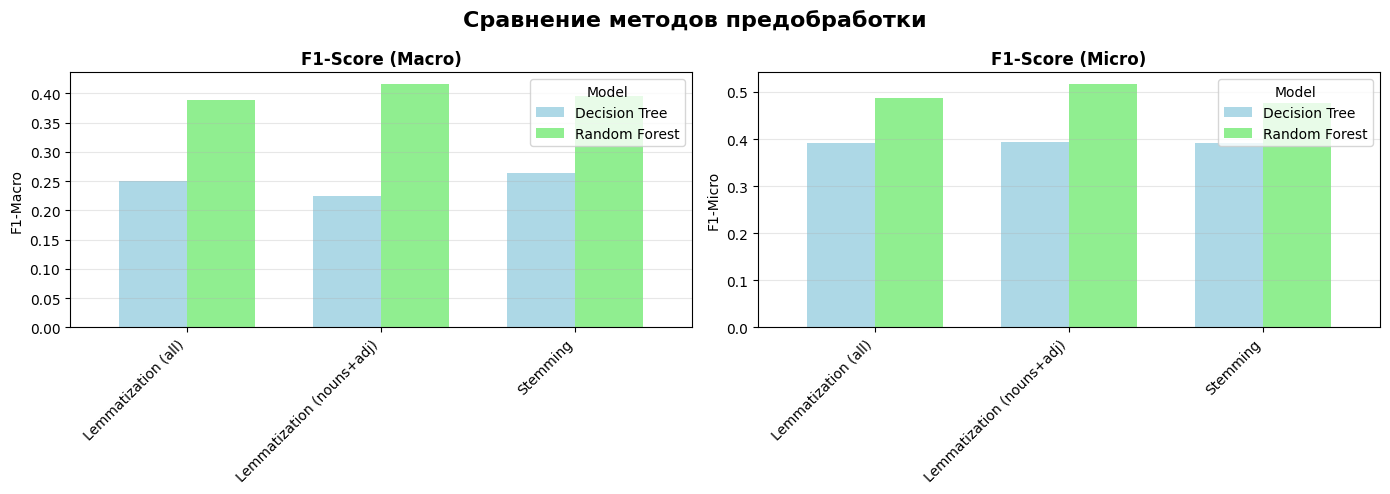


ЛУЧШИЕ РЕЗУЛЬТАТЫ

🏆 Best F1-Macro:
   Preprocessing: Lemmatization (nouns+adj)
   Model: Random Forest
   F1-Macro: 0.4152

🏆 Best F1-Micro:
   Preprocessing: Lemmatization (nouns+adj)
   Model: Random Forest
   F1-Micro: 0.5160

✅ Анализ завершен!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



print("\n" + "="*80)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА: F1-Score на тестовом сете")
print("="*80)

comparison_data = []

for prep_name in preprocessing_methods.keys():
    for model_name in models.keys():
        f1_macro = all_results[prep_name]['test'][model_name]['f1_macro']
        f1_micro = all_results[prep_name]['test'][model_name]['f1_micro']
        
        comparison_data.append({
            'Preprocessing': prep_name,
            'Model': model_name,
            'F1-Macro': f1_macro,
            'F1-Micro': f1_micro
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Сравнение методов предобработки', fontsize=16, fontweight='bold')

# F1-Macro
pivot_macro = comparison_df.pivot(index='Preprocessing', columns='Model', values='F1-Macro')
pivot_macro.plot(kind='bar', ax=axes[0], color=['lightblue', 'lightgreen'], width=0.7)
axes[0].set_title('F1-Score (Macro)', fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].set_xlabel('')
axes[0].legend(title='Model')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# F1-Micro
pivot_micro = comparison_df.pivot(index='Preprocessing', columns='Model', values='F1-Micro')
pivot_micro.plot(kind='bar', ax=axes[1], color=['lightblue', 'lightgreen'], width=0.7)
axes[1].set_title('F1-Score (Micro)', fontweight='bold')
axes[1].set_ylabel('F1-Micro')
axes[1].set_xlabel('')
axes[1].legend(title='Model')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Лучший результат
print("\n" + "="*80)
print("ЛУЧШИЕ РЕЗУЛЬТАТЫ")
print("="*80)
best_macro = comparison_df.loc[comparison_df['F1-Macro'].idxmax()]
best_micro = comparison_df.loc[comparison_df['F1-Micro'].idxmax()]

print("\n🏆 Best F1-Macro:")
print(f"   Preprocessing: {best_macro['Preprocessing']}")
print(f"   Model: {best_macro['Model']}")
print(f"   F1-Macro: {best_macro['F1-Macro']:.4f}")

print("\n🏆 Best F1-Micro:")
print(f"   Preprocessing: {best_micro['Preprocessing']}")
print(f"   Model: {best_micro['Model']}")
print(f"   F1-Micro: {best_micro['F1-Micro']:.4f}")

print("\n✅ Анализ завершен!")

In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Словарь для перебора всех вариантов предобработки
preprocessing_methods = {
    'Lemmatization (all)': 'text_simple',
    'Lemmatization (nouns+adj)': 'text_pos',
    'Stemming': 'text_stem'
}

lstm_results = []

for prep_name, text_col in preprocessing_methods.items():
    print(f"\n{'='*80}")
    print(f"🚀 Обучение LSTM на: {prep_name}")
    print(f"{'='*80}")
    
    
    tf.keras.backend.clear_session()
    import gc; gc.collect()
    
    # 2. Токенизация и паддинг
    tokenizer = Tokenizer(num_words=10000)
    tokenizer.fit_on_texts(train_df[text_col])
    
    X_train = pad_sequences(tokenizer.texts_to_sequences(train_df[text_col]), maxlen=100)
    X_test  = pad_sequences(tokenizer.texts_to_sequences(test_df[text_col]),  maxlen=100)
    
    y_train = train_df['label'].values
    y_test  = test_df['label'].values
    
    # 3. Построение модели (архитектура из твоего PDF, адаптированная под 4 класса)
    model = Sequential([
        Embedding(len(tokenizer.word_index) + 1, 100, input_length=100),
        SpatialDropout1D(0.2),
        LSTM(100, dropout=0.2, recurrent_dropout=0.2),
        Dense(6, activation='softmax')
    ])
    
    model.compile(
        loss='sparse_categorical_crossentropy', 
        optimizer=Adam(learning_rate=0.01), 
        metrics=['accuracy']
    )
    
    # 4. Обучение
    model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
    
    # 5. Предсказание и оценка
    y_pred_proba = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)
    
    f1_macro = f1_score(y_test, y_pred_classes, average='macro', zero_division=0)
    f1_micro = f1_score(y_test, y_pred_classes, average='micro', zero_division=0)
    
    print(f"✅ F1-Macro: {f1_macro:.4f} | F1-Micro: {f1_micro:.4f}")
    
    lstm_results.append({
        'Preprocessing': prep_name,
        'Model': 'LSTM',
        'F1-Macro': f1_macro,
        'F1-Micro': f1_micro
    })


results_df = pd.DataFrame(lstm_results)

print("\n" + "="*80)
print("📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА: LSTM по видам предобработки")
print("="*80)
print(results_df.to_string(index=False))

# Найдем лучший вариант
best_lstm = results_df.loc[results_df['F1-Macro'].idxmax()]
print(f"\n🏆 Лучший LSTM: {best_lstm['Preprocessing']} | F1-Macro: {best_lstm['F1-Macro']:.4f}")


🚀 Обучение LSTM на: Lemmatization (all)


c:\Users\ysnxlmted\Projects\documents_classification\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 80s 325ms/step - accuracy: 0.7692 - loss: 0.6390 - val_accuracy: 0.9187 - val_loss: 0.2172
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 62s 273ms/step - accuracy: 0.9399 - loss: 0.1552 - val_accuracy: 0.9219 - val_loss: 0.1689
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 63s 282ms/step - accuracy: 0.9601 - loss: 0.0986 - val_accuracy: 0.9175 - val_loss: 0.2307
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 75s 335ms/step - accuracy: 0.9747 - loss: 0.0678 - val_accuracy: 0.9200 - val_loss: 0.2595
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 86s 381ms/step - accuracy: 0.9799 - loss: 0.0527 - val_accuracy: 0.9150 - val_loss: 0.2655
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step
✅ F1-Macro: 0.8577 | F1-Micro: 0.9125

🚀 Обучение LSTM на: Lemmatization (nouns+adj)
Epoch 1/5


c:\Users\ysnxlmted\Projects\documents_classification\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


225/225 ━━━━━━━━━━━━━━━━━━━━ 93s 386ms/step - accuracy: 0.6287 - loss: 1.0166 - val_accuracy: 0.7437 - val_loss: 0.7062
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 91s 405ms/step - accuracy: 0.7873 - loss: 0.6163 - val_accuracy: 0.7150 - val_loss: 0.8119
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 108s 256ms/step - accuracy: 0.8472 - loss: 0.4420 - val_accuracy: 0.7125 - val_loss: 0.8864
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 60s 267ms/step - accuracy: 0.8743 - loss: 0.3545 - val_accuracy: 0.7175 - val_loss: 1.0550
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 64s 283ms/step - accuracy: 0.8914 - loss: 0.3022 - val_accuracy: 0.7025 - val_loss: 1.1865
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step
✅ F1-Macro: 0.6217 | F1-Micro: 0.6985

🚀 Обучение LSTM на: Stemming
Epoch 1/5


c:\Users\ysnxlmted\Projects\documents_classification\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 275ms/step - accuracy: 0.7320 - loss: 0.7330 - val_accuracy: 0.9144 - val_loss: 0.2148
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 66s 295ms/step - accuracy: 0.9287 - loss: 0.1769 - val_accuracy: 0.9156 - val_loss: 0.2218
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 74s 329ms/step - accuracy: 0.9563 - loss: 0.1081 - val_accuracy: 0.9094 - val_loss: 0.2314
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 65s 286ms/step - accuracy: 0.9683 - loss: 0.0817 - val_accuracy: 0.9156 - val_loss: 0.2745
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 62s 277ms/step - accuracy: 0.9758 - loss: 0.0656 - val_accuracy: 0.9087 - val_loss: 0.3206
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step
✅ F1-Macro: 0.8481 | F1-Micro: 0.8910

📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА: LSTM по видам предобработки
            Preprocessing Model  F1-Macro  F1-Micro
      Lemmatization (all)  LSTM  0.857688    0.9125
Lemmatization (nouns+adj)  LSTM  0.621695    0.6985
                 Stemming  LSTM  0.848067    0.8910

🏆 Лучший LSTM: Lemm

In [ ]:
from gensim.models import Word2Vec

em_texts_train = dataset['train']['text']

sentences = [text.split() for text in em_texts_train]

# vector_size - размерность вектора, window - контекстное окно, min_count - игнорировать редкие слова
w2v_model = Word2Vec(
    sentences, 
    vector_size=40,   
    window=3,        
    min_count=5,      
    epochs=30,        
    sg=1,             
)

print("Модель Word2Vec обучена!")

Модель Word2Vec обучена!


In [24]:
emo_words = ['happy', 'sad', 'angry', 'scared', 'love', 'amazing', 'feel', 'bad', 'terrible', 'wonderful']

for word in emo_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"Эмоция '{word}':")
        for sim_word, score in similar:
            print(f"  -> {sim_word} ({score:.4f})")
    else:
        print(f"Слово '{word}' не найдено")

Эмоция 'happy':
  -> satisfied (0.7465)
  -> relaxed (0.6974)
  -> excited (0.6874)
Эмоция 'sad':
  -> unhappy (0.7729)
  -> angry (0.7669)
  -> lonely (0.7446)
Эмоция 'angry':
  -> upset (0.8202)
  -> helpless (0.8127)
  -> unhappy (0.7804)
Эмоция 'scared':
  -> anxious (0.7759)
  -> nervous (0.7611)
  -> paranoid (0.7606)
Эмоция 'love':
  -> spoke (0.7190)
  -> regard (0.7002)
  -> hear (0.6808)
Эмоция 'amazing':
  -> award (0.6949)
  -> important (0.6628)
  -> wonderful (0.6480)
Эмоция 'feel':
  -> feeling (0.7069)
  -> smells (0.6577)
  -> socially (0.6503)
Эмоция 'bad':
  -> good (0.7257)
  -> sucks (0.7254)
  -> awful (0.7230)
Эмоция 'terrible':
  -> horrible (0.7461)
  -> rotten (0.7018)
  -> crappy (0.6737)
Эмоция 'wonderful':
  -> exciting (0.6847)
  -> honored (0.6512)
  -> honoured (0.6507)


In [ ]:
em_train_text_cleaned = [preprocess_with_lemmatization(t) for t in em_texts_train]
sentences = [text.split() for text in em_train_text_cleaned]

w2v_model = Word2Vec(
    sentences, 
    vector_size=50,   # Уменьшаем вектор, чтобы его было проще заполнить смыслом
    window=3,         # Берем только самых близких соседей
    min_count=5,      # Игнорируем слова, которые встречаются реже 5 раз
    epochs=30,        
    sg=1              
)

print("Модель Word2Vec обучена!")

Модель Word2Vec обучена!


In [30]:
# 10 характерных слов
emo_words = ['happy', 'sad', 'angry', 'scared', 'love', 'amazing', 'feel', 'bad', 'terrible', 'wonderful']

for word in emo_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"Эмоция '{word}':")
        for sim_word, score in similar:
            print(f"  -> {sim_word} ({score:.4f})")
    else:
        print(f"Слово '{word}' не найдено")

Эмоция 'happy':
  -> tranquil (0.5694)
  -> strain (0.5633)
  -> preparation (0.5542)
Эмоция 'sad':
  -> angry (0.6593)
  -> horribly (0.6537)
  -> hopeless (0.6354)
Эмоция 'angry':
  -> upset (0.7668)
  -> misunderstood (0.7098)
  -> broke (0.7007)
Эмоция 'scared':
  -> alarmed (0.7259)
  -> aggravated (0.7103)
  -> alright (0.7043)
Эмоция 'love':
  -> loved (0.7101)
  -> compassion (0.6946)
  -> care (0.6484)
Эмоция 'amazing':
  -> honour (0.7067)
  -> privilege (0.6968)
  -> wonderful (0.6432)
Эмоция 'feel':
  -> im (0.7104)
  -> soo (0.7099)
  -> feeling (0.7064)
Эмоция 'bad':
  -> besides (0.6751)
  -> officer (0.6171)
  -> lousy (0.6015)
Эмоция 'terrible':
  -> horrible (0.7000)
  -> vicious (0.6496)
  -> rotten (0.6369)
Эмоция 'wonderful':
  -> connect (0.6727)
  -> america (0.6727)
  -> honored (0.6603)
